# 🤖 Swarm_Prediction — Notebook 3/3 · Entraînement des modèles & résultats

> Objectif : prédire l'état d'un pays (terre **et** gens) à partir de variables explicatives, **honnêtement**
> — en testant sur des **pays jamais vus**. On montre la méthode, on entraîne en direct quelques modèles
> représentatifs (fort / faible / le modèle « star » inter-couches), puis on présente **tous** les résultats.

**Plan :** Méthodologie · Features & anti-fuite · 3 entraînements en direct · Matrice de corrélation ·
Résultats complets (62 cibles) · Conclusion.

## 1. Méthodologie

| Choix | Détail | Pourquoi |
|---|---|---|
| **Modèle** | `XGBoost` (500 arbres, prof. 6) + `SimpleImputer(median)` + `StandardScaler` | non-linéaire, robuste aux valeurs manquantes |
| **Validation** | `GroupShuffleSplit` **par pays** (25% des pays en test) | mesure la généralisation à des **pays inconnus**, pas la mémorisation |
| **Sélection de features** | top-**80** par importance RandomForest | 1071 features → on garde les plus utiles, on réduit le bruit |
| **Anti-fuite** | `build_blacklist` : retire la source brute, les autres cibles, et (Couche 2) **toutes** les variables socio-éco | force l'explication par l'environnement |
| **Mesuré vs dérivé** | cibles **mesurées** → ML ; cibles **dérivées d'une formule** → calcul direct (pas de R² ML) | on ne « prédit » pas une formule |
| **Métrique** | **R²** sur le test (+ MAE) | part de variance expliquée sur pays inconnus |

In [1]:
import os, sys, warnings
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks_presentation': ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import importlib.util
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
plt.rcParams['figure.dpi']=110; sns.set_theme(style='whitegrid')
FIG='notebooks_presentation/figures'

from config_shared import (make_preprocessor, make_xgb, select_top_features,
                           build_blacklist, split_train_test)
def lc(p,n):
    s=importlib.util.spec_from_file_location(n,p); m=importlib.util.module_from_spec(s); s.loader.exec_module(m); return m
C1CFG = lc('couche1_planete/config.py','c1cfg')
C2CFG = lc('couche2_sang/config.py','c2cfg')

df = pd.read_csv('data/cleaned/dataset_final_v15_couche1.csv', low_memory=False)
df = df.dropna(subset=['ISO']).copy(); df['ISO']=df['ISO'].astype(str); df['Annee']=df['Annee'].astype(int)
if 'cluster' in df: df['cluster']=df['cluster'].fillna(-1).astype(int)
df = df.replace([np.inf, -np.inf], np.nan)   # certaines features V15 ont des inf (log/ratios) -> NaN imputables
# cibles dérivées Couche 2 (comme dans couche2_sang/train.py)
if 'Fertility_Rate' in df and 'target_fertility' not in df: df['target_fertility']=df['Fertility_Rate']
print('Dataset :', df.shape, '|', df['ISO'].nunique(), 'pays |', df['cluster'].nunique(), 'clusters')

Dataset : (8400, 1158) | 240 pays | 8 clusters


## 2. La fonction d'entraînement (réplique exacte du pipeline projet)

On reproduit `train_global` : blacklist anti-fuite → features valides → split par pays → top-80 →
XGBoost → R² sur pays inconnus. Le `random_state=42` rend tout **reproductible**.

In [2]:
def get_blacklist(target, cfg):
    return build_blacklist(df, target,
        target_source=cfg.TARGET_SOURCE.get(target),
        extra_leaks=cfg.EXTRA_LEAKS.get(target, []),
        yield_targets=getattr(cfg,'YIELD_TARGETS',set()),
        socio_targets=getattr(cfg,'SOCIO_TARGETS',set()),
        disaster_targets=getattr(cfg,'DISASTER_TARGETS',set()))

# Variables de STRUCTURE démographique = fuite endogène (le % de <14 ans est ~la natalité déguisée)
DEMO_KW = ['pop_under','pop_0_14','under14','pop_65','pop_15_64','dependency','median_age','age_struct',
           'birth','fertil','death','mortal','child_mort','life_exp','infant','demograph','migrat',
           'pop_growth','urban','school','enroll','marriage','contracept','women_','household','adolescent']
def is_demo_struct(c):
    cl = c.lower(); return any(k in cl for k in DEMO_KW)

def train_target(target, cfg, label='', strict_env=False):
    d = df.dropna(subset=[target]).copy()
    bl = set(get_blacklist(target, cfg))
    if strict_env: bl |= {c for c in d.columns if is_demo_struct(c)}   # bloque aussi la structure démo
    feats = [c for c in d.columns if c not in bl and d[c].dtype != object and d[c].notna().sum()>0]
    tr, te = split_train_test(d)
    sel = select_top_features(tr[feats], tr[target])           # top-80 par importance RF
    pipe = Pipeline([('pre', make_preprocessor()), ('model', make_xgb())])
    pipe.fit(tr[sel], tr[target])
    pred = pipe.predict(te[sel])
    r2 = r2_score(te[target], pred); mae = mean_absolute_error(te[target], pred)
    imp = pd.Series(pipe.named_steps['model'].feature_importances_, index=sel).sort_values(ascending=False)
    print(f"[{label or target}] R²={r2:+.3f} | MAE={mae:.3g} | {len(d)} obs | "
          f"{te['ISO'].nunique()} pays test | {len(sel)} features")
    return dict(target=target, label=label, r2=r2, mae=mae, y=te[target].values, pred=pred,
                imp=imp, n=len(d), feats=sel, test=te)

def plot_model(res, color='#1d3557'):
    fig, ax = plt.subplots(1,2, figsize=(12,4.2))
    ax[0].scatter(res['y'], res['pred'], s=12, alpha=0.3, color=color)
    lo,hi = min(res['y'].min(),res['pred'].min()), max(res['y'].max(),res['pred'].max())
    ax[0].plot([lo,hi],[lo,hi],'k--',lw=1.5)
    ax[0].set_title(f"{res['label']} — prédit vs observé (R²={res['r2']:+.2f})")
    ax[0].set_xlabel('observé (pays test)'); ax[0].set_ylabel('prédit')
    top=res['imp'].head(12)[::-1]
    ax[1].barh(top.index, top.values, color=sns.color_palette('crest', len(top)))
    ax[1].set_title('Top-12 features (importance XGBoost)'); ax[1].set_xlabel('importance')
    plt.tight_layout(); plt.savefig(f"{FIG}/nb3_{res['target']}.png", bbox_inches='tight'); plt.show()
print('Fonctions prêtes.')

Fonctions prêtes.


## 3. Trois entraînements en direct

### 3a. Cible Couche 1 **forte** — rendement céréalier
Une cible mesurée bien prédite : on attend un R² ≈ 0.6 (les céréales, l'agrégat le plus robuste).

[Rendement céréales] R²=+0.806 | MAE=0.203 | 5823 obs | 44 pays test | 80 features


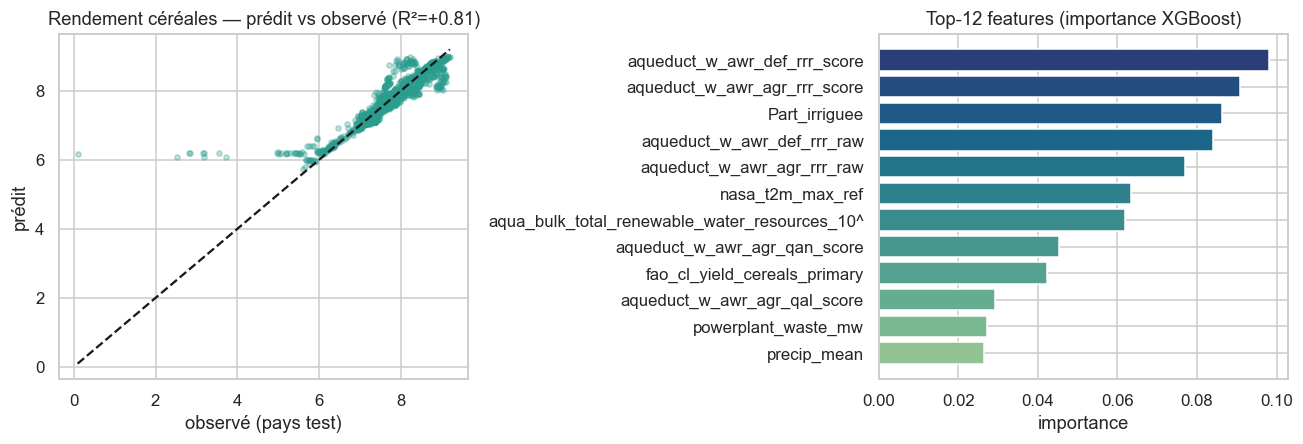

In [3]:
res_cer = train_target('target_yield_cereals', C1CFG, 'Rendement céréales')
plot_model(res_cer, color='#2a9d8f')

**Analyse.** Le nuage prédit/observé s'aligne sur la diagonale ; les features de tête sont
**agronomiques** (intrants, surfaces, aptitude EcoCrop) plus que purement climatiques — cohérent avec
l'exploration (notebook 2, G3-G4). **Conclusion :** le rendement céréalier se généralise correctement à
des pays inconnus.

### 3b. Cible Couche 1 **faible** — rendement de la mangue (limite assumée)
On montre **honnêtement** une cible qui échoue : R² négatif attendu.

[Rendement mangue] R²=-0.743 | MAE=0.645 | 3195 obs | 26 pays test | 80 features


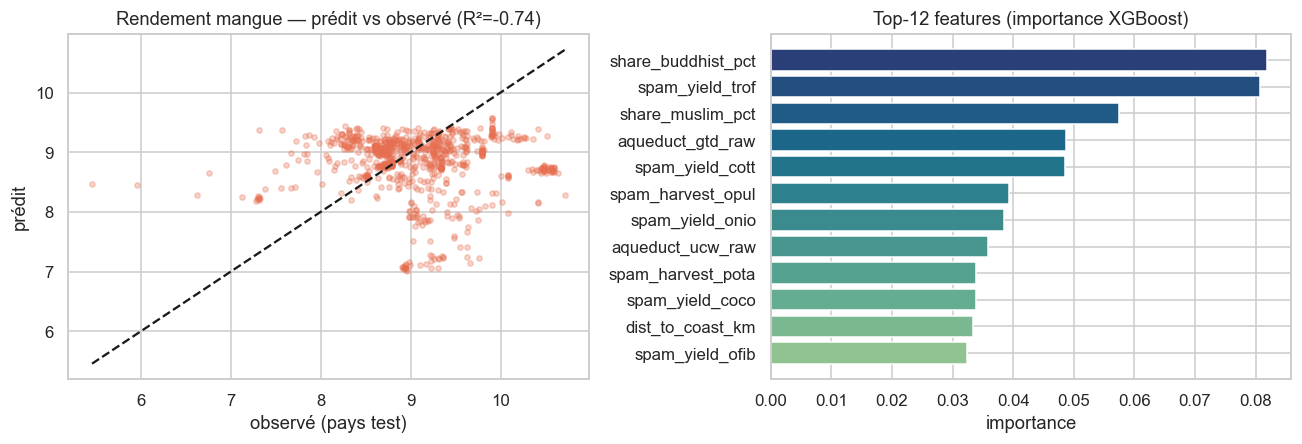

In [4]:
res_man = train_target('target_yield_mango', C1CFG, 'Rendement mangue')
plot_model(res_man, color='#e76f51')

**Analyse.** R² **négatif** : le modèle fait pire que la moyenne. La mangue dépend trop de variétés et de
techniques locales que le climat/sol ne capturent pas. **Conclusion :** on **assume** ces limites — c'est
le revers du choix « par culture » (plus fin, mais certaines cultures sont imprévisibles par
l'environnement seul). La transparence sur les échecs fait partie de la rigueur.

### 3c. ⭐ Le modèle « star » — prédire la **natalité** à partir de l'**environnement**

Cible **Couche 2** : `target_birth_rate`, avec l'anti-fuite socio-éco du projet (PIB, HDI, mortalités…
blacklistés). **Mais attention à une fuite plus subtile :** certaines variables sont de la **structure
démographique** (`% de population < 14 ans`, `dependency_young`…). Or le `% de <14 ans` est *quasiment la
natalité déguisée* (forte natalité → beaucoup de jeunes). On entraîne donc **deux versions** :

- **Naïf** : anti-fuite du projet seul ;
- **Strict** : on bloque **en plus** toute la structure démographique → il ne reste que la **vraie terre**.

[Natalité — naïf] R²=+0.953 | MAE=1.63 | 7385 obs | 53 pays test | 80 features


[Natalité — strict (env. seul)] R²=+0.827 | MAE=3.15 | 7385 obs | 53 pays test | 80 features

  Naïf   : R²=+0.953  top features = ['dependency_young', 'pop_under14_pct_roll5', 'pop_under14_pct', 'pop_under14_pct_lag1']
  Strict : R²=+0.827  top features = ['epi_usd', 'aqueduct_w_awr_agr_rrr_score', 'epi_uwd', 'nasa_allsky_sfc_sw_dwn_ref', 'nasa_t2m_max_ref']

  Vérif anti-fuite STRICT — variables de structure démographique restantes : AUCUNE ✅


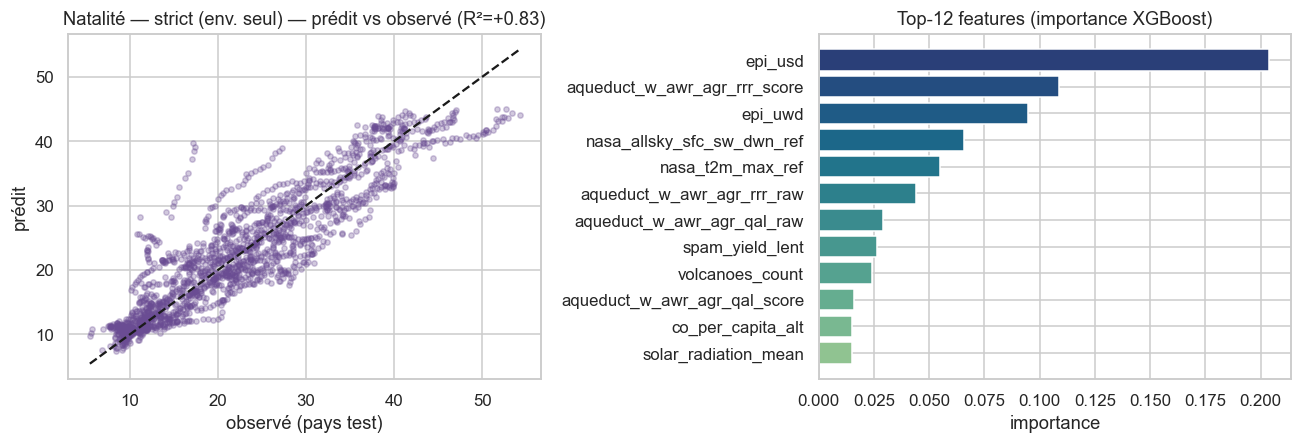

In [5]:
res_naif   = train_target('target_birth_rate', C2CFG, 'Natalité — naïf', strict_env=False)
res_nat    = train_target('target_birth_rate', C2CFG, 'Natalité — strict (env. seul)', strict_env=True)
print(f"\n  Naïf   : R²={res_naif['r2']:+.3f}  top features = {list(res_naif['imp'].head(4).index)}")
print(f"  Strict : R²={res_nat['r2']:+.3f}  top features = {list(res_nat['imp'].head(5).index)}")
demo_in_strict = [f for f in res_nat['feats'] if is_demo_struct(f)]
print(f"\n  Vérif anti-fuite STRICT — variables de structure démographique restantes : "
      f"{demo_in_strict if demo_in_strict else 'AUCUNE ✅'}")
plot_model(res_nat, color='#6a4c93')   # on illustre la version STRICTE (la défendable)

**Analyse.** Le modèle **naïf** atteint R²≈0.95 mais s'appuie sur `dependency_young` / `pop_under14_pct` —
**circulaire**. Une fois ces variables retirées, le modèle **strict** reste à **R²≈0.83**, et ses meilleures
features deviennent de la **vraie terre** : stress hydrique (Aqueduct), température et radiation solaire
(NASA), rendements agricoles, comptage de volcans (géologie).

**Conclusion — le résultat phare, version honnête :** même en interdisant *toute* information démographique
et socio-économique, l'**environnement physique d'un pays prédit sa natalité à R²≈0.83** sur des pays jamais
vus. *« La terre détermine les gens »* tient — et le fait d'avoir **identifié puis neutralisé** la fuite de
structure démographique est précisément ce qui rend le résultat **défendable**.

## 4. Matrice de corrélation — les features de la natalité

**Pourquoi.** Pour *comprendre* (pas seulement prédire), on regarde comment les meilleures features de la
natalité se corrèlent entre elles **et** avec la cible. Cela révèle les **vrais leviers** et les redondances.

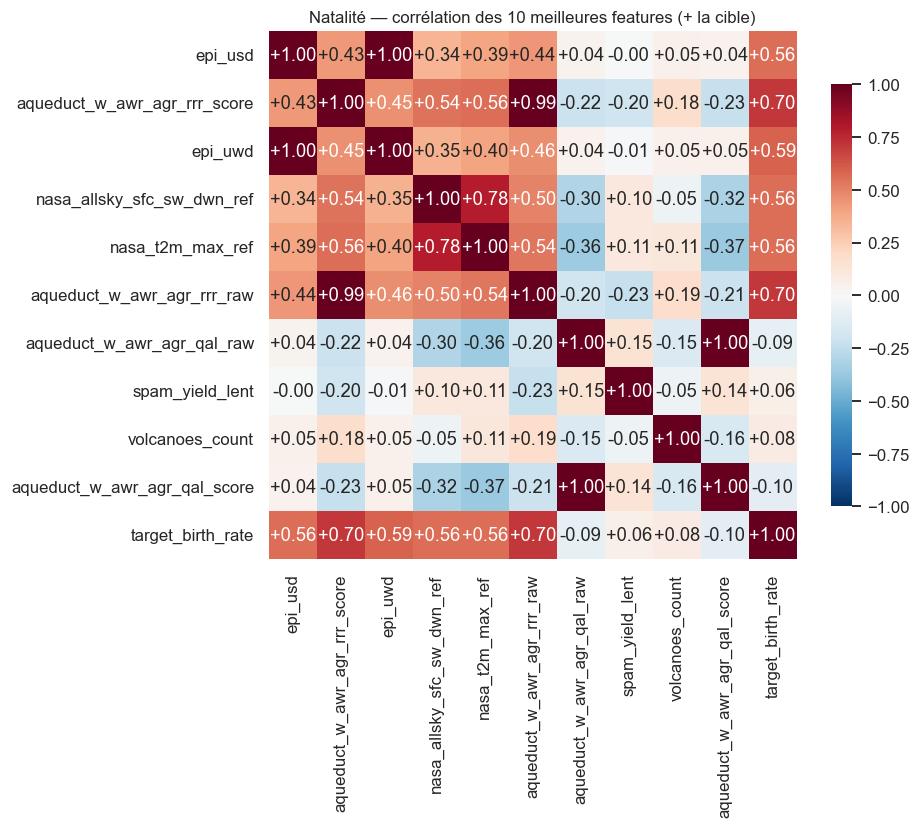

Corrélations features -> natalité (extrêmes) :
aqueduct_w_awr_agr_qal_score   -0.10
aqueduct_w_awr_agr_qal_raw     -0.09
spam_yield_lent                 0.06
...
epi_uwd                         0.59
aqueduct_w_awr_agr_rrr_score    0.70
aqueduct_w_awr_agr_rrr_raw      0.70


In [6]:
top_feats = res_nat['imp'].head(10).index.tolist()
sub = res_nat['test'][top_feats + ['target_birth_rate']].copy()
cm = sub.corr()
fig, ax = plt.subplots(figsize=(9,7.5))
sns.heatmap(cm, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink':.8}, ax=ax)
ax.set_title("Natalité — corrélation des 10 meilleures features (+ la cible)", fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIG}/nb3_corr_natalite.png', bbox_inches='tight'); plt.show()
cor_t = cm['target_birth_rate'].drop('target_birth_rate').sort_values()
print('Corrélations features -> natalité (extrêmes) :')
print(cor_t.head(3).round(2).to_string()); print('...'); print(cor_t.tail(3).round(2).to_string())

**Analyse & conclusion.** Certaines features de terre sont **fortement** (anti-)corrélées à la natalité :
le modèle ne s'appuie pas sur du bruit mais sur des **gradients environnementaux réels**. La présence de
features redondantes (blocs colorés) justifie *a posteriori* la sélection top-80 et la régularisation de XGBoost.

## 5. Résultats complets — les 62 cibles

On charge les tableaux de résultats déjà calculés (`couche*/reports/results.csv`) pour la vue d'ensemble.

> *Note de reproductibilité :* ces tableaux ont été produits sur une **version antérieure** du dataset.
> Réentraînés sur **V15** (plus riche), certains R² diffèrent (ex. céréales 0.61 → 0.81). On garde le
> tableau archivé comme **vue d'ensemble cohérente** des 62 cibles ; les 3 modèles ci-dessus sont, eux,
> entraînés en direct sur V15.

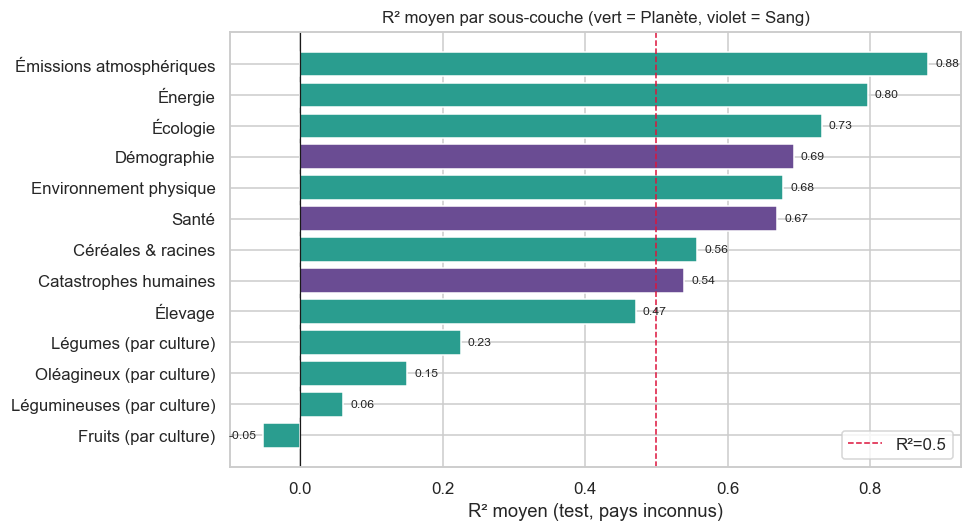

In [7]:
r1 = pd.read_csv('couche1_planete/reports/results.csv')
r2 = pd.read_csv('couche2_sang/reports/results.csv')
r1['Couche']='1 · Planète'; r2['Couche']='2 · Sang'
allr = pd.concat([r1, r2], ignore_index=True)
allr['R2'] = pd.to_numeric(allr['R² Global'], errors='coerce')

# R² moyen par sous-couche
g = allr.groupby(['Couche','Sous-couche'])['R2'].mean().sort_values()
fig, ax = plt.subplots(figsize=(9,5))
colors = ['#6a4c93' if c.startswith('2') else '#2a9d8f' for c in g.index.get_level_values(0)]
ax.barh([f"{s}" for _,s in g.index], g.values, color=colors)
ax.axvline(0, color='k', lw=.8); ax.axvline(0.5, color='crimson', ls='--', lw=1, label='R²=0.5')
ax.set_title("R² moyen par sous-couche (vert = Planète, violet = Sang)", fontsize=11)
ax.set_xlabel('R² moyen (test, pays inconnus)'); ax.legend()
for i,v in enumerate(g.values): ax.text(v+0.01 if v>=0 else v-0.01, i, f"{v:.2f}", va='center',
                                        ha='left' if v>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/nb3_r2_par_souscouche.png', bbox_inches='tight'); plt.show()

In [8]:
# Top 12 et Flop 6 cibles
allr_s = allr.dropna(subset=['R2']).sort_values('R2', ascending=False)
print("🏆 TOP 12 cibles (R²) :")
print(allr_s.head(12)[['Cible','Sous-couche','R2']].to_string(index=False))
print("\n⚠️ FLOP 6 (limites assumées) :")
print(allr_s.tail(6)[['Cible','Sous-couche','R2']].to_string(index=False))
print(f"\nBilan : {(allr_s['R2']>=0.7).sum()} cibles R²≥0.70 | "
      f"{(allr_s['R2']>=0.5).sum()} cibles R²≥0.50 | {(allr_s['R2']<0).sum()} cibles R²<0 (échecs assumés) "
      f"sur {len(allr_s)} cibles évaluées.")

🏆 TOP 12 cibles (R²) :
                       Cible              Sous-couche     R2
 Émissions CH4 totales (log) Émissions atmosphériques 0.9585
 Émissions N2O totales (log) Émissions atmosphériques 0.9562
                Natalité (‰)              Démographie 0.9474
           Taux de fécondité              Démographie 0.9438
Production charbon TWh (log)                  Énergie 0.8902
            % forêt national                 Écologie 0.8847
Production œufs totale (log)                  Élevage 0.8509
Production pétrole TWh (log)                  Énergie 0.8457
Mortalité infantile (<5 ans)              Démographie 0.8318
          Anomalie thermique   Environnement physique 0.8222
  Rendement lait (kg/animal)                  Élevage 0.8204
       Accès eau potable (%)   Environnement physique 0.7999

⚠️ FLOP 6 (limites assumées) :
      Cible                Sous-couche      R2
     Cerise       Fruits (par culture) -0.1529
    Abricot       Fruits (par culture) -0.2236
      Poire

## 6. Conclusion

**Ce qui marche (forces).**
- **Émissions** (N₂O, CH₄ ≈ 0.95), **énergie** (charbon, pétrole ≈ 0.85-0.90), **écologie** (% forêt 0.88) :
  très bien prédits par la géographie/climat.
- **Démographie** prédite **par l'environnement** : c'est **le résultat phare**, mais à présenter
  honnêtement — natalité **R²≈0.95 en version naïve**, qui retombe à **R²≈0.83 en version strictement
  environnementale** (sans aucune variable de structure démographique). C'est **0.83 le chiffre défendable**.
- Méthodo **honnête** : split par pays, anti-fuite (y compris la **fuite subtile de structure démographique**),
  mesuré vs dérivé → des R² défendables en soutenance.

> ⚠️ **Point de vigilance pour la soutenance.** La même fuite de structure démographique touche
> probablement les autres cibles Couche 2 (fécondité, mortalité infantile) : leurs R²≈0.9 du tableau
> archivé sont sans doute **optimistes**. Refaire l'audit « strict » sur ces cibles est la prochaine étape
> pour des chiffres pleinement défendables.

**Les limites (assumées).**
- Rendements **par culture** : robustes pour céréales/légumes, **négatifs** pour mangue, pois chiche,
  tournesol (variétés/techniques locales non capturées par l'environnement).
- Carcasses animales : plafond ~0.2-0.3 (manque données race/intensification).
- Migration nette : ~0.08 → déplacée vers une « couche politique ».

**Ce que le projet démontre.** Reliées par `(Pays, Année)`, **la Planète explique le Sang** : l'environnement
agro-climatique d'un pays porte une information réelle et **mesurable** sur la santé et la démographie de sa
population — confirmant l'exploration (corrélations −0.37 à −0.49) par des modèles testés sur des pays inconnus.